In [1]:
# Import von Bibliotheken
import io,re
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
!pip install wordcloud
from wordcloud import WordCloud

**AUSSCHLIEßLICH Wahlprogramme**

In [2]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [3]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [4]:
# Überführen aller 'eigentlichen' Texte in einen String pro Partei, d.h. ohne Kapitelüberschriften

# für CDU/CSU
CDU_text_str = [text if text.endswith('.') else text + '.' for text in CDU_text]   # ein "Punkt" wird gesetzt bei Bulletpoints
CDU_text = " ".join(CDU_text_str)

# für SPD
SPD_text_str = [text if text.endswith('.') else text + '.' for text in SPD_text]
SPD_text = " ".join(SPD_text_str)

# für Die Linke
Linke_text_str = [text if text.endswith('.') else text + '.' for text in Linke_text]
Linke_text = " ".join(Linke_text_str)

# für die AfD
AfD_text_str = [text if text.endswith('.') else text + '.' for text in AfD_text]
AfD_text = " ".join(AfD_text_str)

# für Bündnis 90/Grüne
Grüne_text_str = [text if text.endswith('.') else text + '.' for text in Grüne_text]
Grüne_text = " ".join(Grüne_text_str)

# für FDP
FDP_text_str = [text if text.endswith('.') else text + '.' for text in FDP_text]
FDP_text = " ".join(FDP_text_str)

In [5]:
# Bereinigung der Texte - TEIL 1 -> um Sonderzeichen usw., siehe Kommentar neben entsprechendem reg-Ausdruck

def str_bereinigen(i):
    i = re.sub(r'-\s+', '', i)                               # Ersetzt den Bindestrich gefolgt von einem oder mehreren Leerzeichen durch nichts
    i = re.sub(r'[^\w\s\.!\?€,,:\(\)\-%]', '', i)            # Sonderzeichen-Filter, löscht alles, was nicht ausdrücklich erhalten bleiben soll
    i = re.sub(r'([A-Za-zÄÖÜäöüß])\1{3,}', r'\1\1\1', i)     # Begrenzung von extremen Wiederholungen
    i = re.sub(r'\s+', ' ', i).strip()                       # Normalisierung von Whitespaces (ersetzt durch ein Leerzeichen)
    return i
    
CDU_text = str_bereinigen(CDU_text)
SPD_text = str_bereinigen(SPD_text)
Grüne_text = str_bereinigen(Grüne_text)
AfD_text = str_bereinigen(AfD_text)
Linke_text = str_bereinigen(Linke_text)
FDP_text = str_bereinigen(FDP_text)

In [6]:
# Bereinigen der zuvor bereinigten Texte - TEIL 2 => Umformen von Abkürzungen in Text um Eindruck von einem Satzende zu vermeiden

def bereinige_abkuerzungen(text):
    # Dictionary mit den Top 20 Ersetzungen (Regex-Muster als Key)
    ersetzungen = {
        r'\bz\.\s*B\.': 'zum Beispiel',   # r'\bz\.\s*B\.\b': 'zum Beispiel',
        r'\bu\.\s*a\.': 'unter anderem',
        r'\bd\.\s*h\.': 'das heißt',
        r'\bbzw\.': 'beziehungsweise',
        r'\bbzw': 'beziehungsweise',   # Variante ohne Punkt
        r'\bsog\.': 'sogenannte',
        r'\bca\.': 'circa',
        r'\bevtl\.': 'eventuell',
        r'\binkl\.': 'inklusive',
        r'\betc\.': 'et cetera',
        r'\bvgl\.': 'vergleiche',
        r'\bs\.': 'siehe',
        r'\bu\.\s*v\.\s*m\.': 'und vieles mehr',
        r'\bu\.\s*ä\.': 'und ähnliche',
        r'\bggf\.': 'gegebenenfalls',
        r'\bzzgl\.': 'zuzüglich',
        r'\bebd\.': 'ebenda',
        r'\bo\.\s*g\.': 'oben genannte',
        r'\bu\.\s*g\.': 'unten genannte',
        r'\bi\.\s*d\.\s*R\.': 'in der Regel',
        r'\bv\.\s*a\.': 'vor allem',

        # 2. Titel & Personen (Verhindern Satzabbruch mitten im Fluss)
        r'\bDr\.': 'Doktor',
        r'\bProf\.': 'Professor',
        r'\bFr\.': 'Frau',
        r'\bHr\.': 'Herr',

        # 3. Wortlaengen- & Silben-Verfaelscher
        r'\bbspw\.': 'beispielsweise',
        r'\bbspw': 'beispielsweise',   # Variante ohne Punkt
        r'\bbsp\.': 'Beispiel',
        r'\bJh\.': 'Jahrhundert',
        r'\bMio\.': 'Millionen',
        r'\bMrd\.': 'Milliarden',
        r'\bbetr\.': 'betreffend',
        r'\bbezgl\.': 'bezüglich',
        r'\bvs\.': 'versus'
    }

    # Text Schritt für Schritt bereinigen
    for muster, ersetzung in ersetzungen.items():
        # flags=re.IGNORECASE sorgt dafür, dass auch "Z.B." oder "Bzw." gefunden werden
        text = re.sub(muster, ersetzung, text, flags=re.IGNORECASE)

    return text

CDU_text = bereinige_abkuerzungen(CDU_text)
SPD_text = bereinige_abkuerzungen(SPD_text)
Grüne_text = bereinige_abkuerzungen(Grüne_text)
AfD_text = bereinige_abkuerzungen(AfD_text)
Linke_text = bereinige_abkuerzungen(Linke_text)
FDP_text = bereinige_abkuerzungen(FDP_text)

In [7]:
# Extrahiert alle Wörter aus den zuvor vorverarbeiteten Texten

CDU_text= re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', CDU_text)
SPD_text = re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', SPD_text)
Linke_text = re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', Linke_text)
Grüne_text = re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', Grüne_text)
AfD_text = re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', AfD_text)
FDP_text = re.findall(r'[a-zA-ZäöüÄÖÜß]+(?:-[a-zA-ZäöüÄÖÜß]+)*', FDP_text)

In [8]:
# Erstellung einer "Substantiv"-Liste; es werden Wörter ausgeklammert, die mit Kleinbuchstaben beginnen

CDU_text = [i for i in CDU_text if not i[0].islower()]
SPD_text = [i for i in SPD_text if not i[0].islower()]
AfD_text = [i for i in AfD_text if not i[0].islower()]
Linke_text = [i for i in Linke_text if not i[0].islower()]
FDP_text = [i for i in FDP_text if not i[0].islower()]
Grüne_text = [i for i in Grüne_text if not i[0].islower()]

In [9]:
# Texte um häufige Satzanfänge, allgemeine politische Füllwörter oder Mengenwörter bereinigen,
# die 'inhaltsleer' sind

löschliste = [
    "AfD", "Art", "Auch", "Beispiel", "Bund", "Bundestagswahl", "Bürger", "CDU",
    "Dabei", "Dafür", "Damit", "Das", "Dazu", "Demokratie", "Demokraten", "Den", "Denn", "Der", "Deshalb",
    "Deutschland", "Deutschlands", "Die", "Dies", "Diese", "Durch", "Ein",
    "Eine", "Es", "Euro","FDP", "Freie", "Für", "Gegen", "Gesellschaft", "Gesetz",
    "Gesetze", "Grüne", "In", "Jahre", "Jahren", "Land", "Linke", "Maßnahmen", "Mehr", "Menschen",
    "Mit", "Oder", "Ohne", "Partei", "Programm", "Prozent", "Regierungsprogramm", "Sie",
    "Sie", "So", "SPD", "Stimme", "Um", "Und", "Unser", "Wahl", "Weg", "Wir",
    "Ziel", "Zudem", "Zukunft"
]

CDU_text = [i for i in CDU_text if i not in löschliste]
SPD_text = [i for i in SPD_text if i not in löschliste]
FDP_text = [i for i in FDP_text if i not in löschliste]
Linke_text = [i for i in Linke_text if i not in löschliste]
AfD_text = [i for i in AfD_text if i not in löschliste]
Grüne_text = [i for i in Grüne_text if i not in löschliste]

In [10]:
# Bildung der Dictionaries, d.h. Zählen der Einzelwörter

CDU_dict = dict()
SPD_dict = dict()
AfD_dict = dict()
Linke_dict = dict()
FDP_dict = dict()
Grüne_dict = dict()

for c in CDU_text:
  CDU_dict[c] = CDU_dict.get(c,0) + 1

for c in SPD_text:
  SPD_dict[c] = SPD_dict.get(c,0) + 1

for c in AfD_text:
  AfD_dict[c] = AfD_dict.get(c,0) + 1

for c in Linke_text:
  Linke_dict[c] = Linke_dict.get(c,0) + 1

for c in FDP_text:
  FDP_dict[c] = FDP_dict.get(c,0) + 1

for c in Grüne_text:
  Grüne_dict[c] = Grüne_dict.get(c,0) + 1

In [11]:
CDU_dict = sorted(CDU_dict.items(), key=lambda x: (-x[1], x[0]))
SPD_dict = sorted(SPD_dict.items(), key=lambda x: (-x[1], x[0]))
AfD_dict = sorted(AfD_dict.items(), key=lambda x: (-x[1], x[0]))
Linke_dict = sorted(Linke_dict.items(), key=lambda x: (-x[1], x[0]))
FDP_dict = sorted(FDP_dict.items(), key=lambda x: (-x[1], x[0]))
Grüne_dict = sorted(Grüne_dict.items(), key=lambda x: (-x[1], x[0]))

In [12]:
# häufigsten 15 Wörter für die Worthäufigkeiten
CDU_dict = CDU_dict[:12]
SPD_dict = SPD_dict[:12]
Grüne_dict = Grüne_dict[:12]
AfD_dict = AfD_dict[:12]
Linke_dict = Linke_dict[:12]
FDP_dict = FDP_dict[:12]

In [13]:
CDU_words = [t[0] for t in CDU_dict]
SPD_words = [t[0] for t in SPD_dict]
Linke_words = [t[0] for t in Linke_dict]
AfD_words = [t[0] for t in AfD_dict]
Grüne_words = [t[0] for t in Grüne_dict]
FDP_words = [t[0] for t in FDP_dict]

In [14]:
text_CDU = " ".join(CDU_words)
text_SPD = " ".join(SPD_words)
text_FDP = " ".join(FDP_words)
text_Linke = " ".join(Linke_words)
text_Grüne = " ".join(Grüne_words)
text_AfD = " ".join(AfD_words)

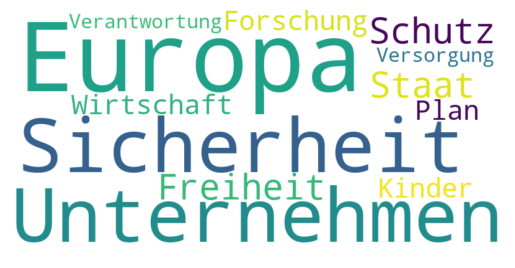

In [15]:
# Beispiel Wordcloud für das CDU/CSU-Wahlprogramm
wc = WordCloud(width=800, height=400, background_color="white")
wc.generate(text_CDU)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [16]:
CDU_pd = pd.DataFrame(CDU_words)
SPD_pd = pd.DataFrame(SPD_words)
Linke_pd = pd.DataFrame(Linke_words)
AfD_pd = pd.DataFrame(AfD_words)
Grüne_pd = pd.DataFrame(Grüne_words)
FDP_pd = pd.DataFrame(FDP_words)

df_combined = pd.concat([CDU_pd, SPD_pd, Linke_pd, AfD_pd, Grüne_pd, FDP_pd], axis=1)
df_combined.columns = ["CDU", "SPD", "Linke", "Afd", "Grüne", "FDP"]
print(df_combined)

              CDU            SPD          Linke          Afd          Grüne  \
0          Europa         Arbeit      Einkommen       Kinder       Kommunen   
1     Unternehmen     Sicherheit    Unternehmen           EU     Sicherheit   
2      Sicherheit         Europa       Kommunen        Recht         Europa   
3        Freiheit    Unternehmen        Kapitel       Eltern    Unternehmen   
4           Staat             EU          Leben        Staat         Schutz   
5          Schutz        Bildung         Arbeit       Schutz  Unterstützung   
6       Forschung       Familien  Beschäftigten  Unternehmen  Investitionen   
7          Kinder  Investitionen             EU     Freiheit        Ländern   
8      Wirtschaft         Schutz     Versorgung       Kosten             EU   
9            Plan        Ländern         Kinder      Staaten          Leben   
10  Verantwortung     Wirtschaft          Recht   Sicherheit         Arbeit   
11     Versorgung       Kommunen        Bildung     

In [17]:
styled_df = df_combined.style.set_table_styles([{"selector": "th", "props": [("font-weight", "bold")]}])
styled_df

,CDU,SPD,Linke,Afd,Grüne,FDP
0,Europa,Arbeit,Einkommen,Kinder,Kommunen,Unternehmen
1,Unternehmen,Sicherheit,Unternehmen,EU,Sicherheit,EU
2,Sicherheit,Europa,Kommunen,Recht,Europa,Sicherheit
3,Freiheit,Unternehmen,Kapitel,Eltern,Unternehmen,Arbeit
4,Staat,EU,Leben,Staat,Schutz,Bildung
5,Schutz,Bildung,Arbeit,Schutz,Unterstützung,Behörden
6,Forschung,Familien,Beschäftigten,Unternehmen,Investitionen,Frauen
7,Kinder,Investitionen,EU,Freiheit,Ländern,Freiheit
8,Wirtschaft,Schutz,Versorgung,Kosten,EU,Staat
9,Plan,Ländern,Kinder,Staaten,Leben,Leben


In [18]:
# in LaTex überführen

latex_code = styled_df.to_latex(caption='Meine Übersicht', label='tab:meine_tabelle')
with open('tabelle_wordcloud.tex', 'w') as f:
    f.write(latex_code)